In [2]:
import numpy as np
from qutip import *
import sys 
import time
import os
np.set_printoptions(
    threshold=np.inf,      # Never truncate rows/columns
    linewidth=150,         # Max characters per line before wrapping
    precision=4,           # Number of decimal places
    suppress=True,          # Suppress scientific notation (e.g., 1e-16 -> 0)
    legacy='1.25'
)
import matplotlib.pyplot as plt
from scipy.special import factorial


# Quantum sensing of magnon number states with a bosonic mode probe



$$
\hat a \ket \alpha = \alpha \ket \alpha
$$
$$
P(n) = \frac{|\alpha|^{2n} e^{-\alpha^2}}{n!}
$$

In [31]:
"""
Quantum sensing of magnon with bosonic mode
"""
# Espacio de Hilbert
Na = 6
Nb = 10

a = tensor(destroy(Na), qeye(Nb))
b = tensor(qeye(Na), destroy(Nb))

r = 0.8
S = squeeze(Na, r)
# Estado inicial
phi_0 = tensor(S*basis(Na,0), basis(Nb, 0))
rho_0 = phi_0 * phi_0.dag()

# Parámetros
o_b = 1
Gamma = 0.003*o_b
X = 0.1*o_b
o_a = 1
d = 0.001*o_b # Driving
T = [0.01 * o_b, 0.5 * o_b , 1*o_b]



# Hamiltoniano estático
H_0 = (
    o_a * a.dag() * a
    + o_b * b.dag() * b
    + X * (a.dag() * a) * (b.dag() * b)
)

# Parte del drive
H_drive = d * (b.dag() + b)

# Función temporal
def drive(t, args):
    return np.cos(args['omega'] * t)

# Hamiltoniano dependiente del tiempo
H = [
    H_0,
    [H_drive, drive]
]
tmax = 15/Gamma
print(
    r'Tr(rho) = ' , rho_0.tr(),
    '\n\n',rho_0.ptrace(1), '\n\n'
    'Pureza : Tr(rho^2) = ' , (rho_0@rho_0).tr(),
    'tmax =', tmax
     )

Tr(rho) =  1.0 

 Quantum object: dims=[[10], [10]], shape=(10, 10), type='oper', dtype=CSR, isherm=True
Qobj data =
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]] 

Pureza : Tr(rho^2) =  1.0000000000000002 tmax = 5000.0


In [41]:
k = d**2 / Gamma**2

n = np.arange(0,Na+1)
alpha = 1

# Probabilidad de encontrar n fotones |<n|alpha>|^2
P_coh = (
    np.exp(-abs(alpha)**2)
    * abs(alpha)**(2*n)
    / factorial(n)
)

omega_res = o_b + X*n


print(k*P_coh)

r = 0.8

# Probability of finding 2n photons |<2n|beta>|^2

m = 2*n  
num = factorial(m) * (np.tanh(r)**m)  # Esto es equivalente a factorial(2*n) * tanh(r)^(2n)
den = (2**m) * (factorial(n)**2) * np.cosh(r)
res = num / den # Llena tambien entradas pares pero deben ser 0

print(k*res)

res[0::2]
P_sqz = np.zeros(Na+1)
P_sqz[0::2] = res[0::2]

k*P_sqz

[0.0409 0.0409 0.0204 0.0068 0.0017 0.0003 0.0001]
[0.0831 0.0183 0.0061 0.0022 0.0009 0.0003 0.0001]


array([0.0831, 0.    , 0.0061, 0.    , 0.0009, 0.    , 0.0001])

In [33]:
cache_file = 'thermal_data_squeezed_weakdrive.npz'

if os.path.exists(cache_file):
    print("Cargando desde caché...")
    data = np.load(cache_file)
    nb_ssT = data['nb_ssT']  # Array 2D: (len(T_list), len(omega_list))
    omega_list = data['omega_list']
    T_list = data['T_list']
    print(f"Datos cargados: {nb_ssT.shape}")
else:
    print("Calculando...")
#--------------------------------------------------------------------------------------------------------------------------------------------
    t = np.arange(0,4000,0.5)
    nb_ssT = [] 
    start_time = time.time()
    for k,T in enumerate(T_list):
     
        nb_ss= []# Lista temp
        # Baño térmico
        n_bth = (np.exp(o_b/T)-1)**(-1)  
        L_ops = [
            np.sqrt(Gamma * (1 + n_bth)) * b,
            np.sqrt(Gamma * n_bth) * b.dag()
        ]
        print(
            f'[{k+1}/{len(T_list)}]',
            f'T = {T:.4f}',
            '\n\n'
        )
        for i, omega in enumerate(omega_list):
        
            evo = mesolve(
                H,
                rho_0,
                t,
                L_ops,
                e_ops=[b.dag() * b],
                args={'omega': omega},
            )   
            nb_t = evo.expect[0]
            
            # Promedio de la parte final (steady-state)
            nb_avg = np.mean(nb_t[-500:])
            nb_ss.append(nb_avg)
            print(
                f'[{i+1}/{len(omega_list)}] '
                f'omega = {omega:.4f}, '
                f'<nb> = {nb_avg:.6f}'
            )
        nb_ssT.append(nb_ss)
        
    elapsed_time = time.time() - start_time
    print(f"Tiempo de cálculo: {(elapsed_time)/60:.2f} min")
#--------------------------------------------------------------------------------------------------------------------------------------------
    # Convertir a array 2D y guardar
    nb_ssT_array = np.array(nb_ssT)
    
    np.savez_compressed(cache_file,
                        nb_ssT=nb_ssT_array,
                        omega_list=omega_list,
                        T_list=T_list)
    print(f"Datos guardados en {cache_file}")

# Ahora nb_ssT es un array numpy, puedes usarlo igual
# Si prefieres lista de listas:
# nb_ssT = nb_ssT.tolist()
# Para cargarlo : data = np.load('thermal_data.npz')

Calculando...
[1/3] T = 0.0100 


[1/22] omega = 0.9000, <nb> = 0.000019
[2/22] omega = 0.9500, <nb> = 0.000076
[3/22] omega = 1.0000, <nb> = 0.083159
[4/22] omega = 1.0500, <nb> = 0.000077
[5/22] omega = 1.1000, <nb> = 0.000023
[6/22] omega = 1.1500, <nb> = 0.000023
[7/22] omega = 1.2000, <nb> = 0.015696
[8/22] omega = 1.2500, <nb> = 0.000018
[9/22] omega = 1.3000, <nb> = 0.000008
[10/22] omega = 1.3500, <nb> = 0.000014
[11/22] omega = 1.4000, <nb> = 0.011597
[12/22] omega = 1.4500, <nb> = 0.000012
[13/22] omega = 1.5000, <nb> = 0.000004
[14/22] omega = 1.5500, <nb> = 0.000002
[15/22] omega = 1.6000, <nb> = 0.000001
[16/22] omega = 1.6500, <nb> = 0.000001
[17/22] omega = 1.7000, <nb> = 0.000001
[18/22] omega = 1.7500, <nb> = 0.000001
[19/22] omega = 1.8000, <nb> = 0.000001
[20/22] omega = 1.8500, <nb> = 0.000001
[21/22] omega = 1.9000, <nb> = 0.000000
[22/22] omega = 1.9500, <nb> = 0.000000
[2/3] T = 0.5000 


[1/22] omega = 0.9000, <nb> = 0.156536
[2/22] omega = 0.9500, <nb> = 0.1565

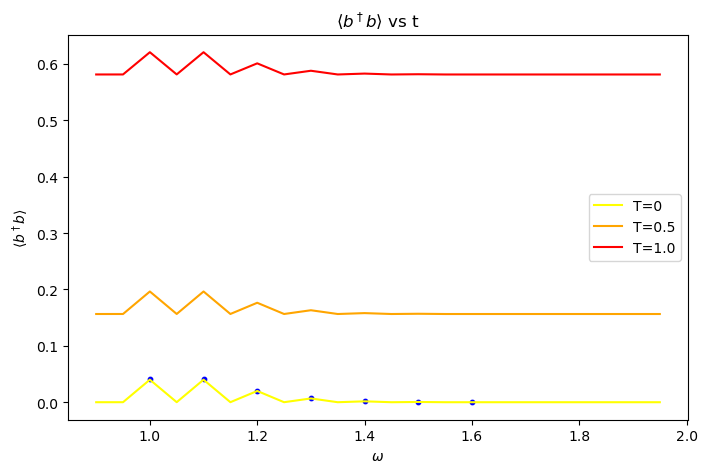

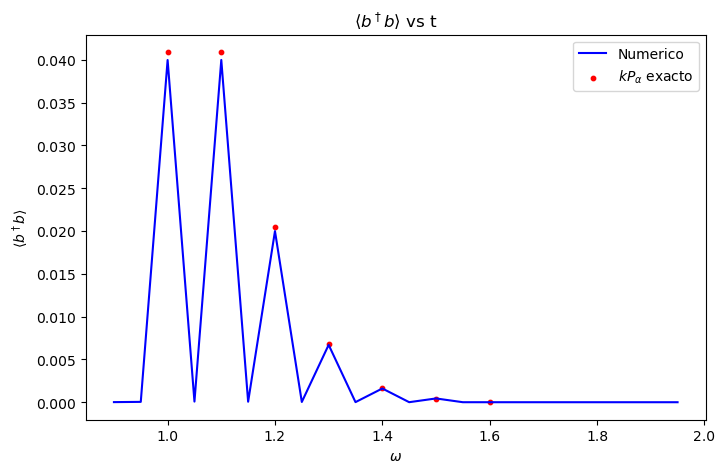

In [68]:
coherent = np.load('thermal_data_coherent.npz')
nb_ssT = coherent['nb_ssT']  # Esto es un array numpy
omega_list = coherent['omega_list']
T_list = coherent['T_list']


plt.figure(figsize=(8,5))


plt.plot(omega_list, nb_ssT[0], c= 'yellow', label='T=0')
plt.plot(omega_list, nb_ssT[1], c= 'orange', label='T=0.5')
plt.plot(omega_list, nb_ssT[2], c= 'red', label='T=1.0')
plt.scatter(omega_res , k*P_coh, c= 'blue', s = 10)

plt.xlabel(r'$\omega$')
plt.ylabel(r'$\langle b^\dagger b\rangle$') 
plt.title(r'$\langle b^\dagger b\rangle$ vs t')
plt.legend()
plt.savefig('nb_vs_omega_withPs_withTs.pdf')
plt.show()

plt.figure(figsize=(8,5))


plt.plot(omega_list, nb_ssT[0], c= 'blue', label = 'Numerico')
plt.scatter(omega_res , k*P_coh, c= 'red', s = 10, label = r'$kP_\alpha$ exacto')


plt.xlabel(r'$\omega$')
plt.ylabel(r'$\langle b^\dagger b\rangle$') 
plt.title(r'$\langle b^\dagger b\rangle$ vs t')
plt.legend()

plt.savefig('nb_vs_omega_withPs.pdf')
plt.show()

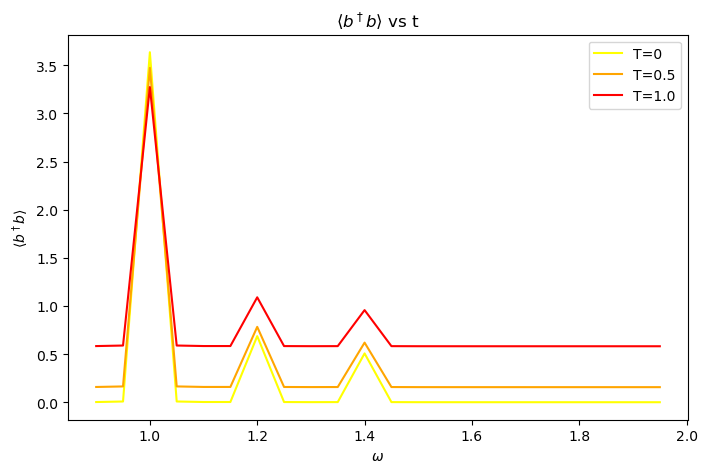

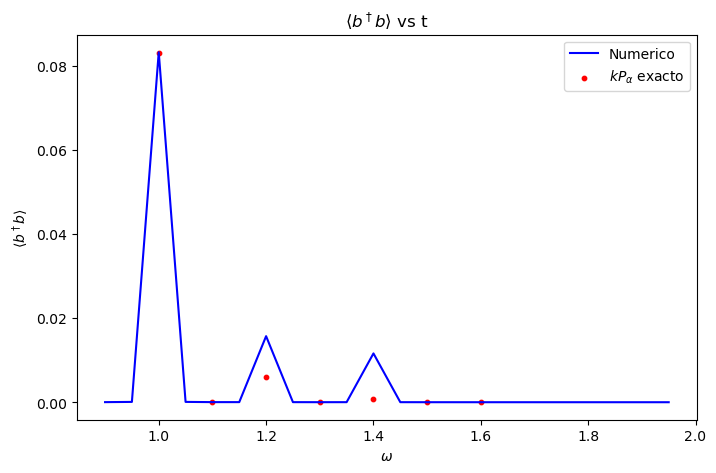

In [36]:
sqz= np.load('thermal_data_squeezed.npz')
nb_ssT = sqz['nb_ssT']  # Esto es un array numpy
omega_list = sqz['omega_list']
T_list = sqz['T_list']

sqzwd = np.load('thermal_data_squeezed_weakdrive.npz')
d = 0.001*o_b
k = d**2 / Gamma**2
nb_ssTwd = sqzwd['nb_ssT']


plt.figure(figsize=(8,5))


plt.plot(omega_list, nb_ssT[0], c= 'yellow', label='T=0')
plt.plot(omega_list, nb_ssT[1], c= 'orange', label='T=0.5')
plt.plot(omega_list, nb_ssT[2], c= 'red', label='T=1.0')
#plt.scatter(omega_res , k*P_sqz, c= 'blue', s = 10)

plt.xlabel(r'$\omega$')
plt.ylabel(r'$\langle b^\dagger b\rangle$') 
plt.title(r'$\langle b^\dagger b\rangle$ vs t')
plt.legend()
plt.savefig('nb_vs_omega_withPs_withTs.pdf')
plt.show()

plt.figure(figsize=(8,5))


plt.plot(omega_list, nb_ssTwd[0], c= 'blue', label = 'Numerico')
plt.scatter(omega_res , k*P_sqz, c= 'red', s = 10, label = r'$kP_\alpha$ exacto')


plt.xlabel(r'$\omega$')
plt.ylabel(r'$\langle b^\dagger b\rangle$') 
plt.title(r'$\langle b^\dagger b\rangle$ vs t')
plt.legend()

plt.savefig('nb_vs_omega_withPs.pdf')
plt.show()